#### Checking for differences between endotype A and B in GCS

This was done to explore the idea of TBI

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# import data of PCA, pro and clin
pca_df = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/PCA_24.csv', index_col=0)
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
clin = clin.drop(labels = [1578], axis = 0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

# preprocessing
prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)  

In [226]:
shap_df = pd.DataFrame(pca_df)
shap_df.index = pca_df.index
bottom_left = shap_df[(shap_df.iloc[:,0]<=0.05) & (shap_df.iloc[:,1]<0.03)]
bottom_right = shap_df[(shap_df.iloc[:,0]>=0.05) & (shap_df.iloc[:,1]<-0.05)]
bottom_right.shape
bottom = bottom_left.append(bottom_right)
bottom.shape

# top section of the plot
top_index=[]
for i in shap_df.index:
    if i not in bottom.index:
        top_index.append(i)
top = shap_df.filter(items = top_index, axis = 0)
bottom_index = bottom.index
print(len(top)+len(bottom))

414


In [227]:
# filter data to get what you need
clin_top = clin.filter(items = top.index, axis = 0)
clin_bottom = clin.filter(items = bottom.index, axis = 0)

top_gcs = clin.filter(items = top.index, axis = 0)['admission_gcs']
bottom_gcs = clin.filter(items = bottom.index, axis = 0)['admission_gcs']
top_15 = clin_top[clin_top['iss']>15]['admission_gcs']
bottom_15 = clin_bottom[clin_bottom['iss']>15]['admission_gcs']

df_gcs = pd.DataFrame(top_gcs.append(bottom_gcs).append(top_15).append(bottom_15))
group = ['TOP_ALL']* len(top_gcs) +['BOTTOM_ALL']* len(bottom_gcs)+['TOP>15']*len(top_15)+ ['BOTTOM >15']*len(bottom_15)
df_gcs['group'] = group

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


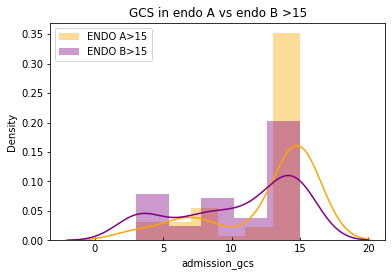

In [231]:
sns.distplot(bottom_15, label = "ENDO A>15", color = 'orange')
sns.distplot(top_15, label = "ENDO B>15", color = 'purple')
plt.legend()
plt.title("GCS in endo A vs endo B >15")
plt.savefig('/Users/smasarone/Documents/endoA_B_gcs.pdf', format = 'pdf')

### Plot GCS for each group

Text(0.5, 1.0, 'GCS in each group')

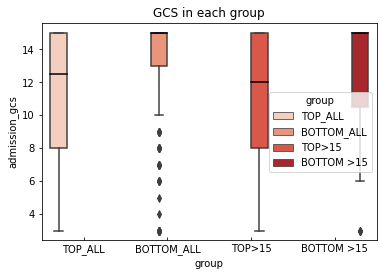

In [140]:
# box
plt.figure(figsize = (6, 4))
sns.boxplot(x = df_gcs['group'], 
            y = df_gcs['admission_gcs'],
            hue = df_gcs['group'],
            palette = 'Reds',
    medianprops={"color": "black"})
plt.title('GCS in each group')

Text(0.5, 1.0, 'Mean values for each group')

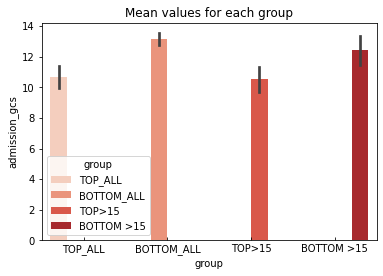

In [141]:
plt.figure(figsize = (6, 4))
sns.barplot(x = df_gcs['group'], 
            y = df_gcs['admission_gcs'],
            hue = df_gcs['group'],
            palette = 'Reds',
           )
plt.title("Mean values for each group")

In [142]:
# get average gcs value in each group
df_gcs.groupby(['group']).mean().round(3)

,admission_gcs
group,
BOTTOM >15,12.469
BOTTOM_ALL,13.163
TOP>15,10.579
TOP_ALL,10.676


/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


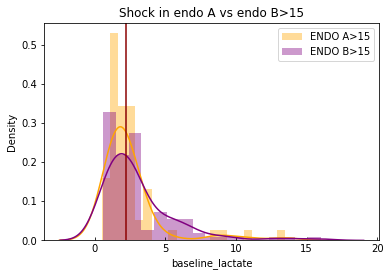

In [230]:
### Plot A vs B with shock
# lactate >2.2
lactate_top = clin_top[clin_top['iss']>15]['baseline_lactate']
lactate_bottom = clin_bottom[clin_bottom['iss']>15]['baseline_lactate']
sns.distplot(lactate_bottom, label = "ENDO A>15", color = 'orange')
sns.distplot(lactate_top, label = "ENDO B>15", color = 'purple')
plt.legend()
plt.title('Shock in endo A vs endo B>15')
plt.axvline(2.2, color = 'darkred')
plt.savefig('/Users/smasarone/Documents/endoA_B_shock.pdf', format = 'pdf')

In [144]:
# endo B good vs endo B bad
table_g = pd.read_csv("/Users/smasarone/Downloads/trauma_clinical_with_endotypes (1).csv", index_col = 0)

(77, 2)
(66, 2)


/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


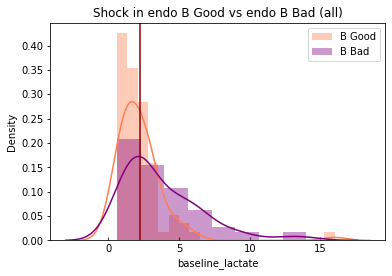

In [145]:
outcomes = table_g.loc[:,'Endotype':'Outcome']
B = outcomes[outcomes['Endotype']=='Endo-B']
Bg = B[B['Outcome']=='GOOD']
Bb = B[B['Outcome']=='BAD']
print(Bg.shape)
print(Bb.shape)

Lactate_bg = clin_top.filter(items = Bg.index, axis = 0)['baseline_lactate']
Lactate_bb = clin_top.filter(items = Bb.index, axis = 0)['baseline_lactate']

sns.distplot(Lactate_bg, label = "B Good", color = 'coral')
sns.distplot(Lactate_bb, label = "B Bad", color = 'purple')
plt.legend()
plt.title('Shock in endo B Good vs endo B Bad (all)')
plt.axvline(2.2, color = 'darkred')
plt.savefig('/Users/smasarone/Documents/endoB_good_bad.pdf', format = 'pdf')

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


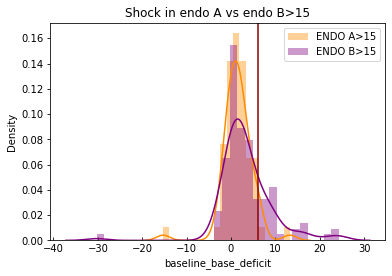

In [146]:
#Base deficit
bd_top = clin_top[clin_top['iss']>15]['baseline_base_deficit']
bd_bottom = clin_bottom[clin_bottom['iss']>15]['baseline_base_deficit']
sns.distplot(bd_bottom, label = "ENDO A>15", color = 'darkorange')
sns.distplot(bd_top, label = "ENDO B>15", color = 'purple')
plt.legend()
plt.title('Shock in endo A vs endo B>15')
plt.axvline(6.0, color = 'darkred')
plt.savefig('/Users/smasarone/Documents/endoA_B_bd.pdf', format = 'pdf')


In [147]:
# get percentage for each injury type
clin_top['injury_code'].value_counts(normalize=True)

8. Fall from height                    0.251748
1. Pedestrian vs vehicle               0.209790
2. Motorcycle vs other vehicle         0.083916
4. Car vs vehicle                      0.076923
10. Jump from height                   0.076923
3. Car vs stationary object            0.048951
14. Cyclist vs vehicle                 0.041958
12. Cyclist                            0.034965
15. Motorcycle vs stationary object    0.034965
17. Crush injury                       0.034965
16. Hit by train/tram                  0.027972
5. Pedestrian vs motorcycle            0.027972
9. Blunt assault                       0.027972
6. Pedestrian vs falling object        0.013986
21. Other                              0.006993
Name: injury_code, dtype: float64

In [148]:
# percentage for endotype A
clin_bottom['injury_code'].value_counts(normalize=True)

1. Pedestrian vs vehicle               0.243542
8. Fall from height                    0.206642
2. Motorcycle vs other vehicle         0.151292
4. Car vs vehicle                      0.070111
9. Blunt assault                       0.062731
14. Cyclist vs vehicle                 0.059041
3. Car vs stationary object            0.040590
17. Crush injury                       0.040590
21. Other                              0.025830
15. Motorcycle vs stationary object    0.025830
5. Pedestrian vs motorcycle            0.022140
6. Pedestrian vs falling object        0.022140
16. Hit by train/tram                  0.014760
10. Jump from height                   0.011070
12. Cyclist                            0.003690
Name: injury_code, dtype: float64

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, '1. Pedestrian vs vehicle'),
  Text(1, 0, '8. Fall from height'),
  Text(2, 0, '2. Motorcycle vs other vehicle'),
  Text(3, 0, '4. Car vs vehicle'),
  Text(4, 0, '9. Blunt assault'),
  Text(5, 0, '14. Cyclist vs vehicle'),
  Text(6, 0, '3. Car vs stationary object'),
  Text(7, 0, '17. Crush injury'),
  Text(8, 0, '21. Other'),
  Text(9, 0, '15. Motorcycle vs stationary object'),
  Text(10, 0, '5. Pedestrian vs motorcycle'),
  Text(11, 0, '6. Pedestrian vs falling object'),
  Text(12, 0, '16. Hit by train/tram'),
  Text(13, 0, '10. Jump from height'),
  Text(14, 0, '12. Cyclist')])

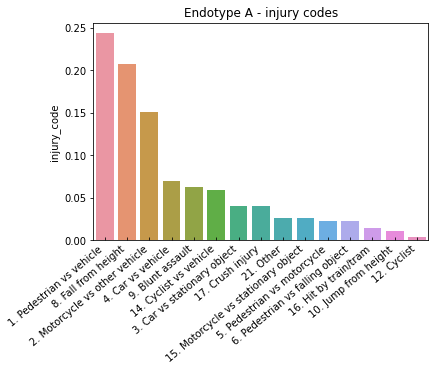

In [149]:
# get the n injury codes for endotype A all
plt.title("Endotype A - injury codes")
sns.barplot(clin_bottom['injury_code'].value_counts(normalize=True).index, clin_bottom['injury_code'].value_counts(normalize=True))
plt.xticks(rotation=40, ha='right') 

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, '8. Fall from height'),
  Text(1, 0, '1. Pedestrian vs vehicle'),
  Text(2, 0, '2. Motorcycle vs other vehicle'),
  Text(3, 0, '4. Car vs vehicle'),
  Text(4, 0, '10. Jump from height'),
  Text(5, 0, '3. Car vs stationary object'),
  Text(6, 0, '14. Cyclist vs vehicle'),
  Text(7, 0, '12. Cyclist'),
  Text(8, 0, '15. Motorcycle vs stationary object'),
  Text(9, 0, '17. Crush injury'),
  Text(10, 0, '16. Hit by train/tram'),
  Text(11, 0, '5. Pedestrian vs motorcycle'),
  Text(12, 0, '9. Blunt assault'),
  Text(13, 0, '6. Pedestrian vs falling object'),
  Text(14, 0, '21. Other')])

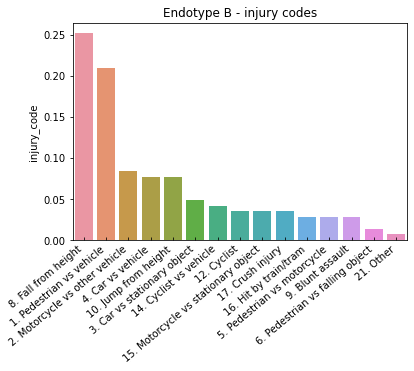

In [150]:
# get the n injury codes for endotype B all
plt.title("Endotype B - injury codes")
sns.barplot(clin_top['injury_code'].value_counts(normalize=True).index, clin_top['injury_code'].value_counts(normalize=True))
plt.xticks(rotation=40, ha='right') 

#### Get histograms for endotype A/B

In [151]:
# filter dataset by top
def get_data_ais(g_table, lista):
    g_table_top = g_table.filter(items = lista, axis = 0)
    return g_table_top['head_neck_ais']


EndoA AIS n* 271


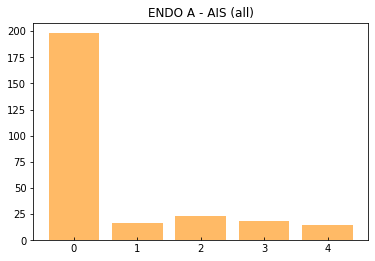

In [213]:
from matplotlib import ticker
top_ais = get_data_ais(table_g, clin_top.index)
bottom_ais = get_data_ais(table_g, clin_bottom.index)

labels, count = np.unique(bottom_ais, return_counts=True)
plt.bar(labels, count, color = 'darkorange', alpha=0.6) # green
plt.title("ENDO A - AIS (all)")
plt.savefig('/Users/smasarone/Documents/endoA_AIS_all.pdf', format = 'pdf')
print("EndoA AIS n* {}".format(len(bottom_ais)))


EndoB AIS n* 143


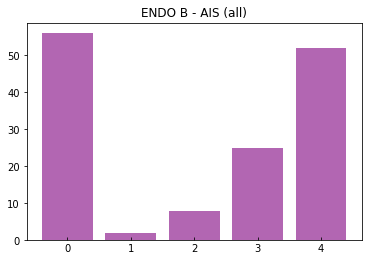

In [212]:
labels, count = np.unique(top_ais, return_counts=True)
plt.bar(labels, count, color = 'purple', alpha = 0.6)
plt.title("ENDO B - AIS (all)")
print("EndoB AIS n* {}".format(len(top_ais)))
plt.savefig('/Users/smasarone/Documents/endoB_AIS_all.pdf', format = 'pdf')

In [154]:
assert len(top_ais) + len(bottom_ais) == 414

### AIS above ISS >15

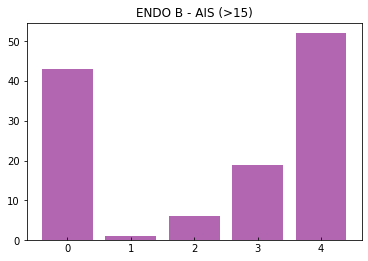

In [214]:
# looking at the ones above 15
clin_15 = table_g[table_g['iss']>15]
clin_15.shape
top_ais15 = get_data_ais(clin_15, clin_top.index)
bottom_ais15 = get_data_ais(clin_15, clin_bottom.index)

# endo A
labels, count = np.unique(top_ais15, return_counts=True)
plt.bar(labels, count, color = 'purple', alpha = 0.6)
plt.title("ENDO B - AIS (>15)")
plt.savefig('/Users/smasarone/Documents/endoB_15_AIS_all.pdf', format = 'pdf')

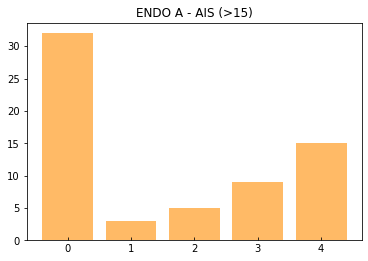

In [217]:
# endoB
labels, count = np.unique(bottom_ais15, return_counts=True)
plt.bar(labels, count, color = 'darkorange', alpha = 0.6)
plt.title("ENDO A - AIS (>15)")
plt.savefig('/Users/smasarone/Documents/endoA_15_AIS_all.pdf', format = 'pdf')

In [157]:
print("Patients in endo B > 15: {}".format(len(top_ais15)))
print("Patients in endo A > 15: {}".format(len(bottom_ais15)))

Patients in endo B > 15: 121
Patients in endo A > 15: 64


In [158]:
# get the percentages for endotype B all
top_ais.value_counts(normalize=True)

0    0.391608
4    0.363636
3    0.174825
2    0.055944
1    0.013986
Name: head_neck_ais, dtype: float64

In [159]:
# Endotype A all
bottom_ais.value_counts(normalize=True)

0    0.730627
2    0.084871
3    0.066421
1    0.062731
4    0.055351
Name: head_neck_ais, dtype: float64

In [160]:
# endotype A >15
bottom_ais15.value_counts(normalize=True)

0    0.500000
4    0.234375
3    0.140625
2    0.078125
1    0.046875
Name: head_neck_ais, dtype: float64

In [161]:
# endotype B >15
top_ais15.value_counts(normalize=True)

4    0.429752
0    0.355372
3    0.157025
2    0.049587
1    0.008264
Name: head_neck_ais, dtype: float64

In [196]:
b_good.value_counts(normalize=True)

0    0.506494
4    0.246753
3    0.168831
2    0.051948
1    0.025974
Name: head_neck_ais, dtype: float64

In [206]:
Bb.shape

(66, 2)

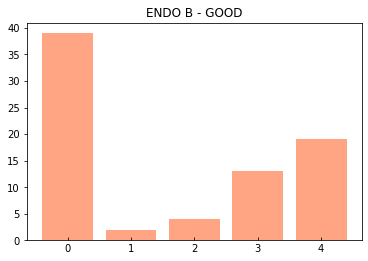

In [222]:
### EndoB good vs BAD

b_good = get_data_ais(table_g, Bg.index)
labels, count = np.unique(b_good, return_counts=True)

plt.bar(labels, count, color = 'coral', alpha = 0.70)
plt.title("ENDO B - GOOD")
plt.savefig('/Users/smasarone/Documents/endoB_good.pdf', format = 'pdf')




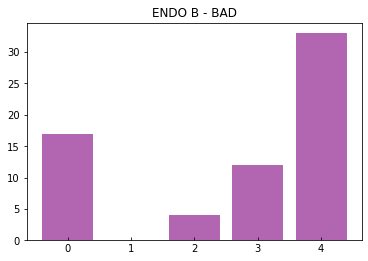

In [224]:
b_bad = get_data_ais(table_g, Bb.index)
labels, count = np.unique(b_bad, return_counts=True)

plt.bar(labels, count, color = 'purple', alpha = 0.6)
plt.title("ENDO B - BAD")
plt.savefig('/Users/smasarone/Documents/endoB_bad.pdf', format = 'pdf')


In [208]:
b_bad.value_counts(normalize=True) 

4    0.500000
0    0.257576
3    0.181818
2    0.060606
Name: head_neck_ais, dtype: float64